In [1]:
print('Importing relevant modules ...')
import warnings
warnings.filterwarnings('ignore',category=RuntimeWarning)
import os
import numpy as np
from tqdm import tqdm
import random
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pylab import rcParams
import matplotlib
from matplotlib import rc;rc('text', usetex=True);rc('font', weight='bold');matplotlib.rcParams['text.latex.preamble'] = r'\boldmath'
rcParams['font.family'] = 'serif'
rc('text.latex',preamble=r'\usepackage{/Users/kevinlevy/Documents/cluster_lensing/files/apjfonts}')
from mpl_toolkits.axes_grid1 import make_axes_locatable
color_arr = ['olivedrab', 'steelblue', 'goldenrod', 'indianred', 'darkgrey']
import cosmo
import mockobs
import stats
import ilc

Importing relevant modules ...


In [2]:
print('Defining relevant parameters ...')
nber_clus = 2500
nber_runs = 20
nx = 120
ny = 120
dx = 0.5
dy = 0.5
reso_arcmin = 0.5
map_params = [nx, dx, ny, dy]
beam_fwhm = 1.4 # arcmin
l = np.arange(10001)
cl = cosmo.cmb_power_spectra(l)['TT']
bl = mockobs.beam_power_spectrum(beam_fwhm, l)
experiments = ['spt3g', 'so', 'so_fyst', 's4wide']
mass_reso = 0.01
mass_min = 0.0
mass_max = 3.0
mass_int = np.arange(mass_min, mass_max, mass_reso)

# for plotting
xmin, xmax = -nx*reso_arcmin/2, nx*reso_arcmin/2
ymin, ymax = -ny*reso_arcmin/2, ny*reso_arcmin/2 
extent_arcmin = [xmin, xmax, ymin, ymax]
extent_degrees = np.asarray(extent_arcmin)/60
fontsize = 19
labelsize = 16
    
save_loc_results = '/Users/kevinlevy/Documents/cluster_lensing/results/forecasts'
if not os.path.exists(save_loc_results):
    os.makedirs(save_loc_results)


Defining relevant parameters ...


In [3]:
fontsize = 21
labelsize = 18
legendsize = 16

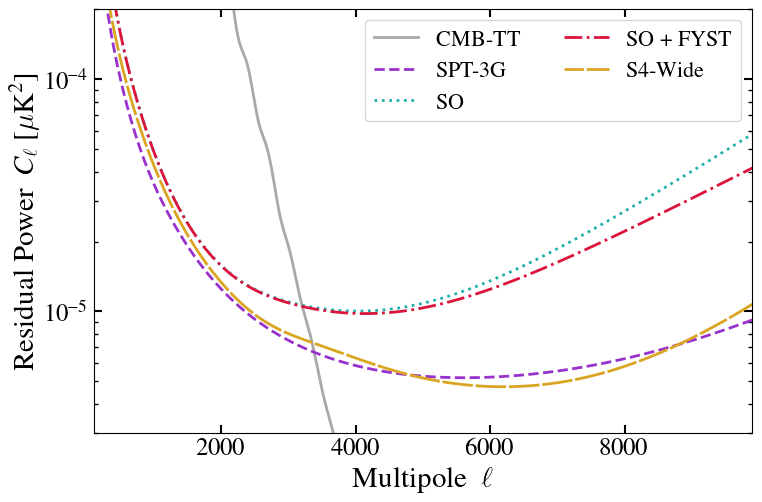

In [4]:
cl_noise_arr = []
for exp in experiments:
    cl_noise = np.load(save_loc_results+'/residuals_'+exp+'.npy', allow_pickle=True)
    cl_noise_arr.append(cl_noise)

fig, ax = plt.subplots(figsize=(8.5,5.5))
color_arr = ['darkorchid', 'lightseagreen', 'crimson', 'goldenrod', 'darkgrey']
ax.set_yscale('log')
label_arr = ['SPT-3G', 'SO', 'SO + FYST', 'S4-Wide']
ls_arr = ['--', ':', '-.', (16, (11,1))]
linewidth = 2
ax.plot(l, cl, label = 'CMB-TT', color = color_arr[-1], ls = '-', linewidth = linewidth)
for i, exp in enumerate(experiments):
    _, _, res_ilc_dic, _ = ilc.residuals_and_weights(components = 'all', experiment = exp, cov_from_sims = True)
    ax.plot(l, cl_noise_arr[i]-res_ilc_dic['ksz'], label = label_arr[i], color = color_arr[i], ls = ls_arr[i], linewidth = linewidth)
ax.set_ylabel('Residual Power '+r'$ \ C_\ell \ [\mu$'+'K'+r'$^2]$', fontsize = fontsize)
ax.set_xlabel('Multipole '+r' \ $\ell$', fontsize = fontsize)
ax.tick_params(labelsize = labelsize)
ax.tick_params(direction='in', axis='both', length=6, width=1, which = 'major', top = 'on', bottom = 'on', left = 'on', right = 'on', labelsize = labelsize)
ax.tick_params(direction='in', axis='both', length=3, width=1, which = 'minor', top = 'on', bottom = 'on', left = 'on', right = 'on', labelsize = labelsize)
ax.set_xlim(100, 9900)
ax.set_ylim(3e-6, 2e-4)
ax.tick_params(labelsize = labelsize, length = 5.5, width = 1.5)
ax.legend(loc = 1, ncol = 2, prop={'size': legendsize}) 
plt.show()

fig.savefig(save_loc_results+'/residuals.pdf', dpi = 200., bbox_inches = 'tight', pad_inches = 0.1)

In [6]:
print('Checking likelhihood curves ...')
L_arr_sorted = np.load(save_loc_results+'/likelihoods.npy', allow_pickle=True)
L_ip_arr_sorted = np.load(save_loc_results+'/likelihoods_finer.npy', allow_pickle=True)
nber_runs = 10
s,e = 0,10
L_arr_sorted = [L_arr_sorted[0][s:e], L_arr_sorted[1][s:e], L_arr_sorted[2][s:e], L_arr_sorted[3][s:e]]
L_ip_arr_sorted = [L_ip_arr_sorted[0][s:e], L_ip_arr_sorted[1][s:e], L_ip_arr_sorted[2][s:e], L_ip_arr_sorted[3][s:e]]
mass_int_finer = np.arange(min(mass_int),max(mass_int),0.001) 
comb_L_arr = []
comb_L_ip_arr = []
comb_median_mass_arr = []
comb_error_arr = []
for i in range(len(L_arr_sorted)):   
    x_comb, L_comb, median_value_comb, error_comb = stats.combined_likelihood(mass_int, L_arr_sorted[i], normalize = True, finer_reso = False)
    print(median_value_comb, error_comb) 
    comb_L_arr.append(L_comb)
    M_ip_comb, L_ip_comb, median_value_comb_finer, error_comb_finer = stats.combined_likelihood(mass_int, L_arr_sorted[i], normalize = True, finer_reso = True)
    print(median_value_comb_finer, error_comb_finer) 
    comb_L_ip_arr.append(L_ip_comb)
    comb_median_mass_arr.append(median_value_comb_finer)
    comb_error_arr.append(error_comb_finer)
combined_median_masses_results_file = ''
for i in range(len(comb_median_mass_arr)):
    combined_median_masses_results_file += "{0:11.2f}{1:>1}{2:5.2f}".format(comb_median_mass_arr[i], "+-", comb_error_arr[i]) + "\n"  
    
    
file = open(save_loc_results+'/mass_results.txt',"w")
file.write(combined_median_masses_results_file)
file.close()
#comb_L_arr = np.load(save_loc_results+'/comb_likelihoods.npy', allow_pickle=True)
#comb_L_ip_arr = np.load(save_loc_results+'/comb_likelihoods_finer.npy', allow_pickle=True)


def signal_to_noise(lnpdf):
    delta_chisq = 2*(max(lnpdf) - lnpdf[0])
    snr = np.sqrt(delta_chisq)
    return snr

snr_spt_3g = signal_to_noise(np.log(comb_L_ip_arr[0]))
snr_so = signal_to_noise(np.log(comb_L_ip_arr[1]))
snr_fyst = signal_to_noise(np.log(comb_L_ip_arr[2]))
snr_s4wide = signal_to_noise(np.log(comb_L_ip_arr[3]))

snr_arr = [snr_spt_3g, snr_so, snr_fyst, snr_s4wide]
np.save(save_loc_results+'/snr.npy', snr_arr) 

snr_results = "{0:11.3f}".format(snr_spt_3g) + "\n"
snr_results = "{0:11.3f}".format(snr_so) + "\n"
snr_results += "{0:11.3f}".format(snr_fyst) + "\n"          
snr_results += "{0:11.3f}".format(snr_s4wide) + "\n"

file = open(save_loc_results+'/snr.txt',"w")
file.write(snr_results)
file.close() 

Checking likelhihood curves ...
1.3788189181435921 0.048178606749548214
1.3785878345674987 0.04806637422959803
1.3435529618610875 0.054819495904800286
1.343338770609257 0.0547121155311574
1.4082089842333985 0.054873379266704214
1.4081103662632968 0.05472149512080482
1.3169846570699622 0.04614623127224726
1.3168939480660742 0.04593139635840615


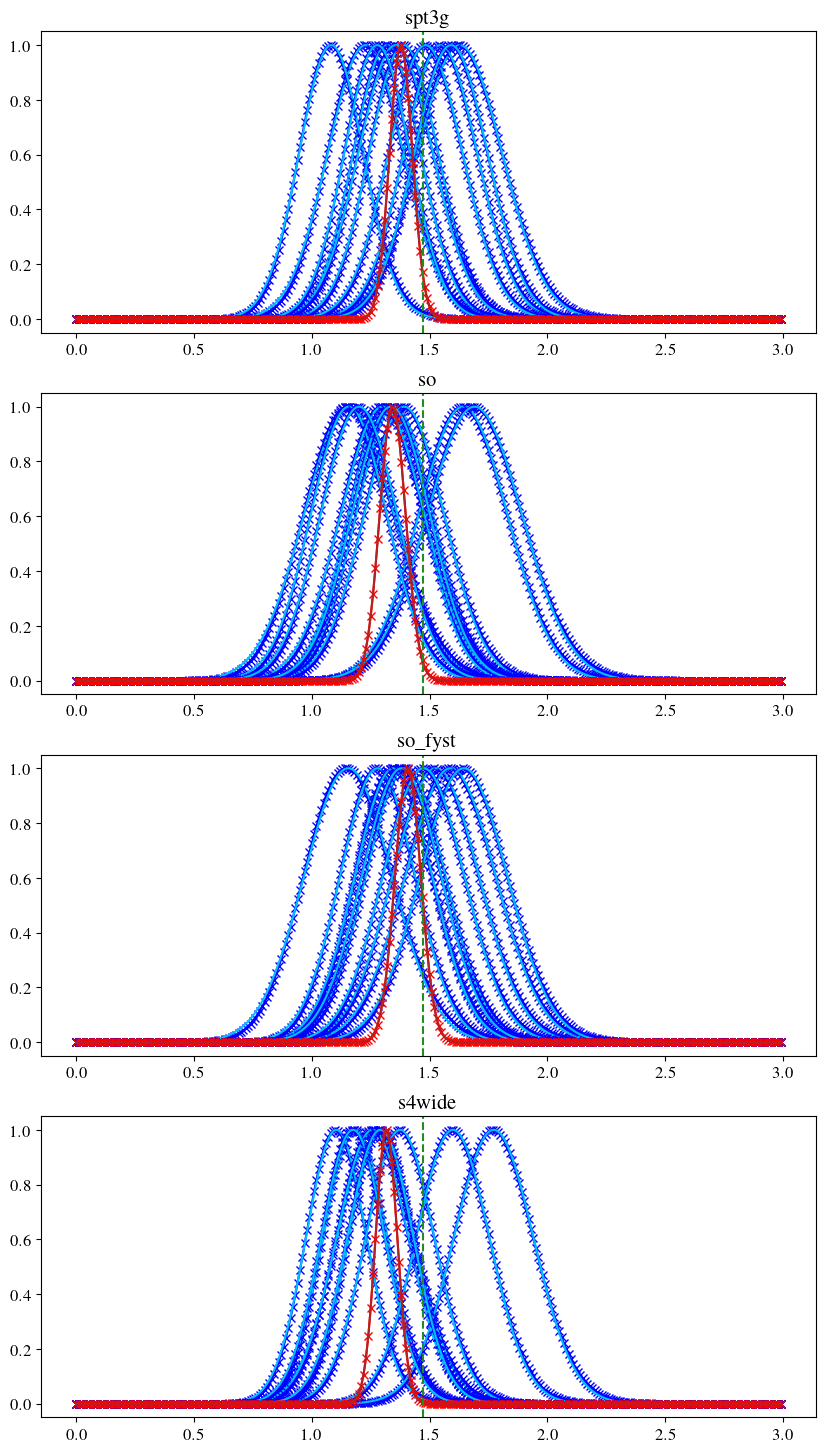

In [7]:
fig, axarr = plt.subplots(len(L_arr_sorted), 1, figsize=(10,18))
start = 0
end = 10000
start_finer = 0
end_finer = 10000
M_input = 1.47e14
for i in range(len(axarr)):
    titstr = experiments[i]
    axarr[i].set_title(titstr, fontsize = fontsize-6)
    for j in  range(10):
        axarr[i].plot(mass_int[start:end], L_arr_sorted[i][j][start:end], ls = '-', marker = 'x', color = 'blue')
        axarr[i].plot(mass_int_finer[start_finer:end_finer], L_ip_arr_sorted[i][j][start_finer:end_finer], ls = '-', marker = '', color = 'deepskyblue')   
    axarr[i].plot(mass_int[start:end], comb_L_arr[i][start:end], ls = '-', marker = 'x', color = 'red')
    axarr[i].plot(mass_int_finer[start_finer:end_finer], comb_L_ip_arr[i][start_finer:end_finer], ls = '-', marker = '', color = 'firebrick')
    axarr[i].axvline(M_input*1e-14, color = 'forestgreen', ls = '--')
   # axarr[i].set_xlabel(r'$M_{200c}\ $'+'[10M_\sun]', fontsize = fontsize-6)
   # axarr[i].set_ylabel(r'$\text{Normalized}\ $'+'\mathcal{L}', fontsize = fontsize-6)
    axarr[i].tick_params(labelsize = labelsize-6)
plt.show()

[15.08084605366612, 24.41070136765355, 25.59798548711678, 56.997219026620435]
[6.63092771 4.09656398 3.90655741 1.75447156]


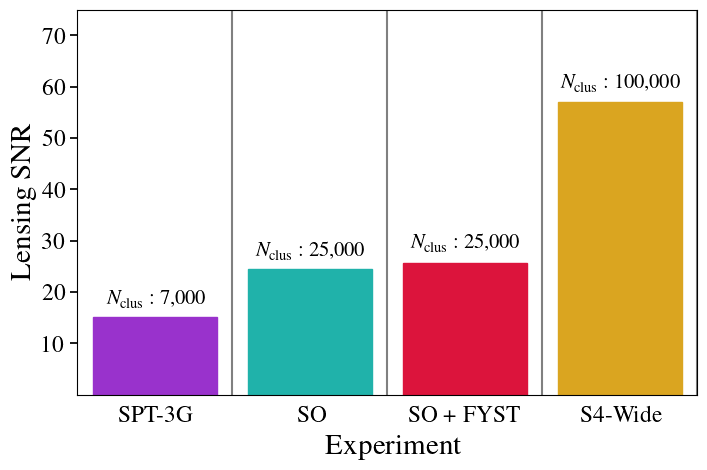

In [8]:
snr_arr = np.load(save_loc_results+'/snr.npy') 
scale_fracs = [np.sqrt(7000/(nber_runs*nber_clus)), np.sqrt(25000/(nber_runs*nber_clus)), np.sqrt(25000/(nber_runs*nber_clus)), np.sqrt(100000/(nber_runs*nber_clus))]
snr_arr_scaled = [snr_arr[i]*scale_fracs[i] for i in range(len(snr_arr))]
print(snr_arr_scaled)
print(100./np.asarray(snr_arr_scaled))
snr_dic={}

#experiments - 
cases_arr=['']
snr_dic['spt3g']=[snr_arr_scaled[0]]
snr_dic['so']=[snr_arr_scaled[1]] #list contains SNR for baseline, with centroid shifts, with kSZ, with tSZ correction, all
snr_dic['so_fyst']=[snr_arr_scaled[2]] #list contains SNR for baseline, with centroid shifts, with kSZ, with tSZ correction, all
snr_dic['s4wide']=[snr_arr_scaled[3]] #list contains SNR for baseline, with centroid shifts, with kSZ, with tSZ correction, all
exp_dic = {'spt3g': 'SPT-3G', 'so': 'SO', 'so_fyst': 'SO + FYST', 's4wide': 'S4-Wide'}
nber_dic = {'spt3g': r'$N_{\rm clus}:$' ' 7,000', 'so': r'$N_{\rm clus}:$' ' 25,000', 
            'so_fyst': r'$N_{\rm clus}:$' ' 25,000', 's4wide': r'$N_{\rm clus}:$' ' 100,000'}

#make bar plots
fsval = 12
yscale_val = None #'log'
ymin, ymax = 0., 75.
exparr = snr_dic.keys()
xcntr = 0.
barwidth = 1.
exp_gap = barwidth * 2.
xincrement = exp_gap*barwidth
hatch_arr = ['///', '\\\\\\', 'xxx', 'ooo']
#ax = subplot(111, yscale = yscale_val)
fig, ax = plt.subplots(figsize=(8,5))
for expcntr, expname in enumerate( exparr ): #loop for experiments
    snr_arr = snr_dic[expname]
    ax.bar(xcntr, snr_arr[0], width = barwidth+0.6, color = color_arr[expcntr], 
           edgecolor = color_arr[expcntr], fill = True, hatch=hatch_arr[expcntr])
    xcntr += barwidth
    xcntr += xincrement - 1
    ax.axvline(xcntr-1, color = 'gray') 
ax.tick_params(direction='in', axis='x', length=0, width=0, which = 'major', top = False, bottom = 'on', left = 'on', right = 'on', labelsize = labelsize)
ax.set_ylim(ymin, ymax)
ax.set_xlim(-1, xcntr - xincrement + 1)

plt.setp(ax.get_xticklabels(which = 'both'), visible=False)
yloc = [ymin-5.2, ymin-5.2, ymin-5.2, ymin-5.2]
xcntr = [-0.48, 1.83, 3.262, 5.49]
for expcntr, expname in enumerate( exparr ):
    ax.text(xcntr[expcntr], yloc[expcntr], exp_dic[expname], fontsize = labelsize-1.1)
    
ax.text(2.2, ymin-11.5, 'Experiment', fontsize = fontsize)

yloc = [ymin+17.5, ymin+27, ymin+28.5, ymin+59.7]
xcntr = [-0.6224, 1.29, 3.2935, 5.234]
for expcntr, expname in enumerate( exparr ):
    ax.text(xcntr[expcntr], yloc[expcntr], nber_dic[expname], fontsize = legendsize-1.0)
    
ax.tick_params(axis='y', length=5.25, width=1.25, which = 'major', left = 'on', right = False, labelsize = labelsize)
ax.set_yticks([10, 20, 30, 40, 50, 60, 70])
ax.set_ylabel('Lensing SNR', fontsize = fontsize)
for label in ax.get_xticklabels(): label.set_fontsize(labelsize-1)
for label in ax.get_yticklabels(): label.set_fontsize(labelsize-1)

plt.savefig(save_loc_results+'/forecasts.pdf', dpi = 200., bbox_inches = 'tight', pad_inches = 0.1)
